In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251010_100920.log


In [2]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [4]:
dye = ["Nile Red"]

In [5]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [6]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

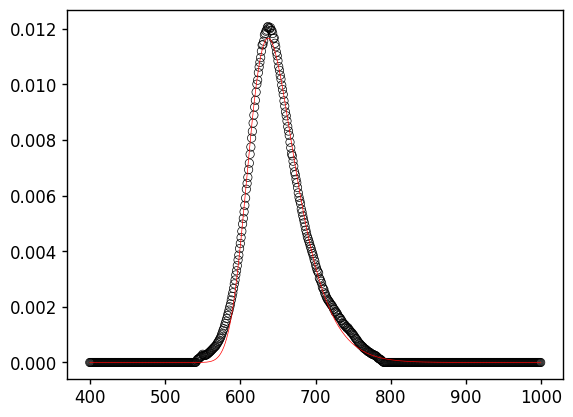

In [7]:
plt.scatter(wavelength, dye_spectrum.T, lw=0.5, color='black', facecolors="none")
plt.plot(wavelength, fitted_spectrum, lw=0.5, color='red')

In [8]:
S_F.wavelength_to_energy(result.x[1])

617.64726490051953

In [9]:
result.x[1:]

array([ 2.00736254,  0.16301003, -1.5645261 ])

In [10]:
# from https://www.sciencedirect.com/science/article/pii/0003269787901576
dielectric_constant = np.array([80, 64, 58, 44 ,37, 27, 34, 44, 24, 18, 11, 18, 38, 37, 21])
emission = np.array([665, 657, 655, 653, 652, 644, 642, 635, 635, 633, 633, 628, 627, 625, 615])

In [11]:
eV = S_F.wavelength_to_energy(emission)

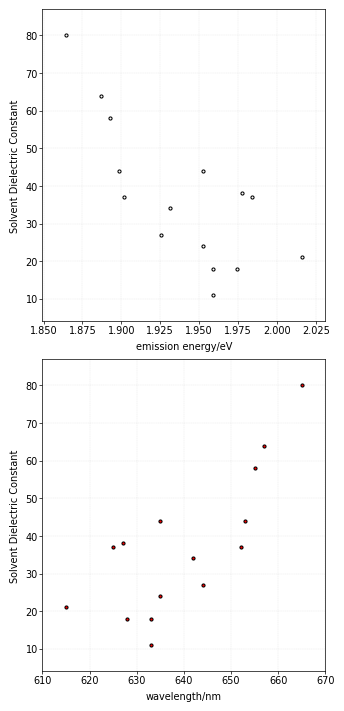

In [12]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1])

axs[0] = plotter.scatter_plot(axs[0], eV, dielectric_constant,
                          xaxislabel='emission energy/eV',
                          yaxislabel='Solvent Dielectric Constant')

axs[1] = plotter.scatter_plot(axs[1], emission, dielectric_constant, facecolor='red',
                          xaxislabel='wavelength/nm', yaxislabel='Solvent Dielectric Constant')

In [13]:
from src import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [ ]:
n_photon_space = np.logspace(np.log10(500), np.log10(20000), 25)

NR_F.simulate_wavelength_precision(
      save_folder="/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting",
      wavelength_range=(580, 680),
      wavelength_step=5,
      photon_counts=n_photon_space,
      n_bootstrap=10000,
      image_size = 16,
      background_photons = 40,
      camera_parameters=camera_parameters,
      verbose=False,
      use_tqdm=False,
  )